#PreProcessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
df = pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [ ]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
df[['scaled_time', 'scaled_amount']] = scaler.fit_transform(df[['Time', 'Amount']])
df.drop(['Time', 'Amount'], axis=1, inplace=True)
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_time,scaled_amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996583,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996583,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-1.996562,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-1.996562,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-1.996541,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,1.641931,-0.350151
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,1.641952,-0.254117
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,1.641974,-0.081839
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,1.641974,-0.313249


In [ ]:
df = df.drop('Class', axis=1).assign(Class=df['Class'])
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,scaled_time,scaled_amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,-1.996583,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.996583,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,-1.996562,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,-1.996562,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-1.996541,-0.073403,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,1.641931,-0.350151,0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,1.641952,-0.254117,0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,1.641974,-0.081839,0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,1.641974,-0.313249,0


In [ ]:
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 1081


In [ ]:
df= df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#EDA

In [ ]:
# Handle outliers using Z-score method
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).all(axis=1)  # Identify outliers (Z-score > 3)
print(f"Number of outlier rows: {outliers.sum()}")

Number of outlier rows: 0


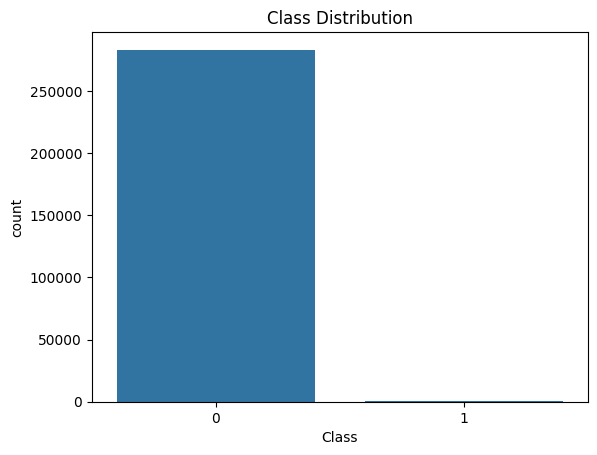

Fraudulent transactions: 0.1667%


In [ ]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

# Percentage of fraud cases
fraud_percent = df['Class'].value_counts(normalize=True)[1] * 100
print(f"Fraudulent transactions: {fraud_percent:.4f}%")


In [ ]:
minority_class_count = y.value_counts()[1]
majority_class_target = minority_class_count * 4
sampling_strategy = {0: min(majority_class_target, y.value_counts()[0]), 1: minority_class_count}

under_sampler = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = under_sampler.fit_resample(X, y)

print("Class distribution after under-sampling:\n", pd.Series(y_resampled).value_counts())


Class distribution after under-sampling:
 Class
0    1892
1     473
Name: count, dtype: int64


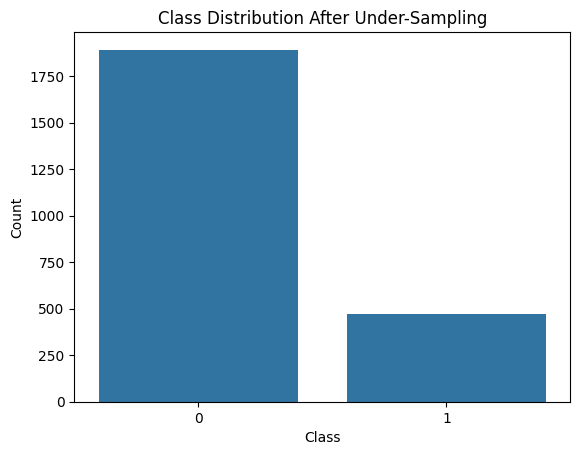

In [ ]:
sns.countplot(x=y_resampled)
plt.title("Class Distribution After Under-Sampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


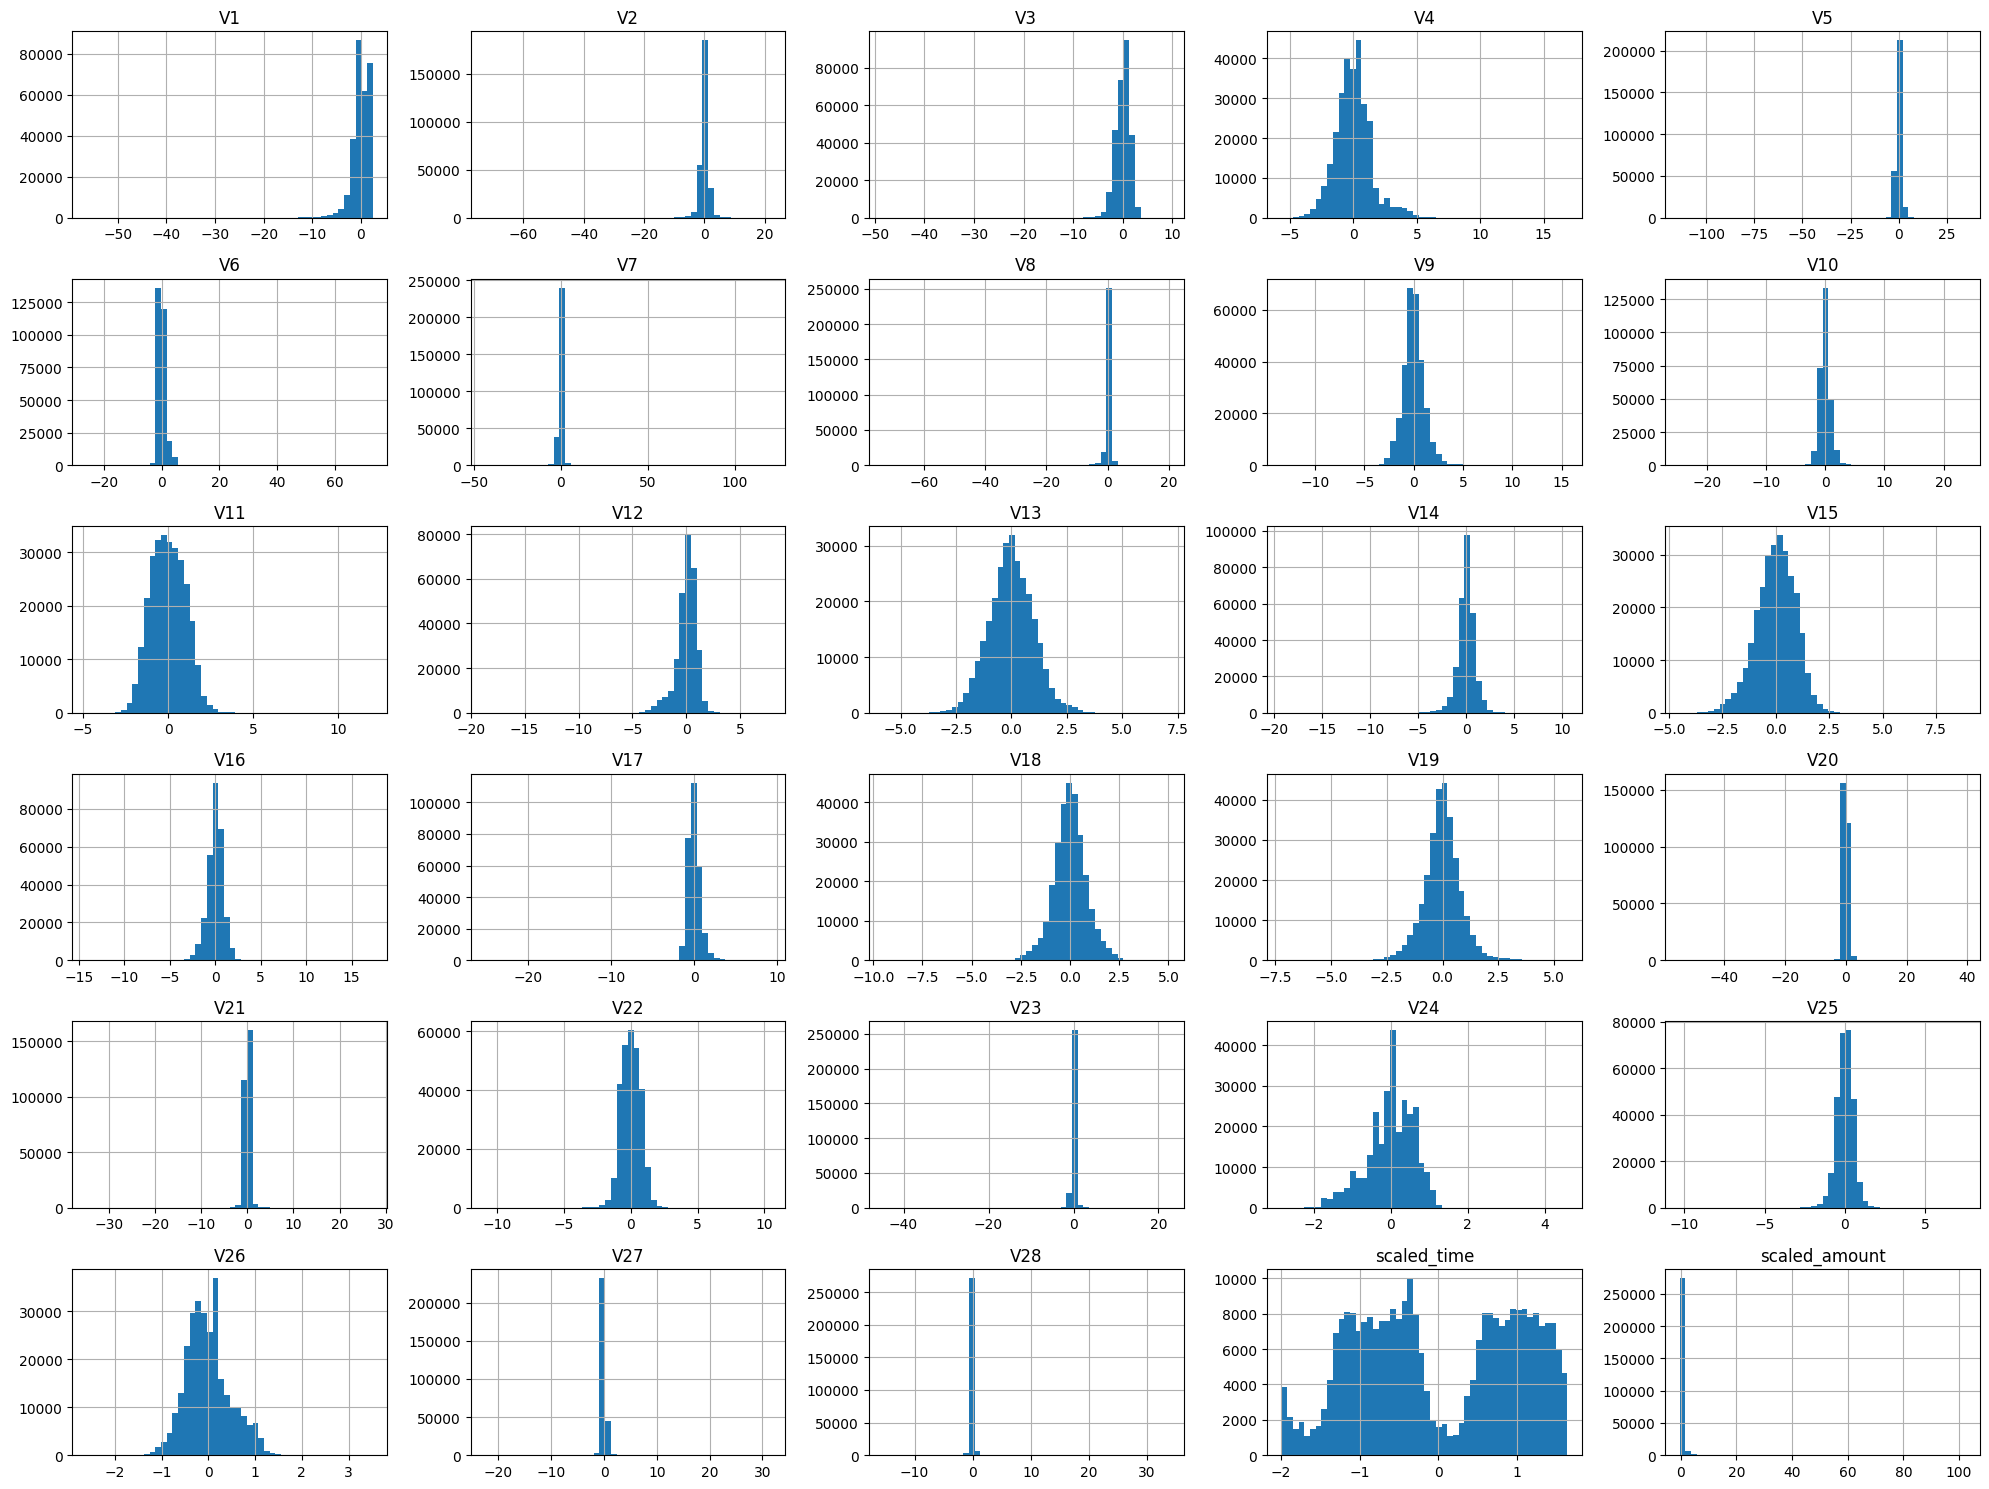

In [ ]:
df.drop('Class', axis=1).hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

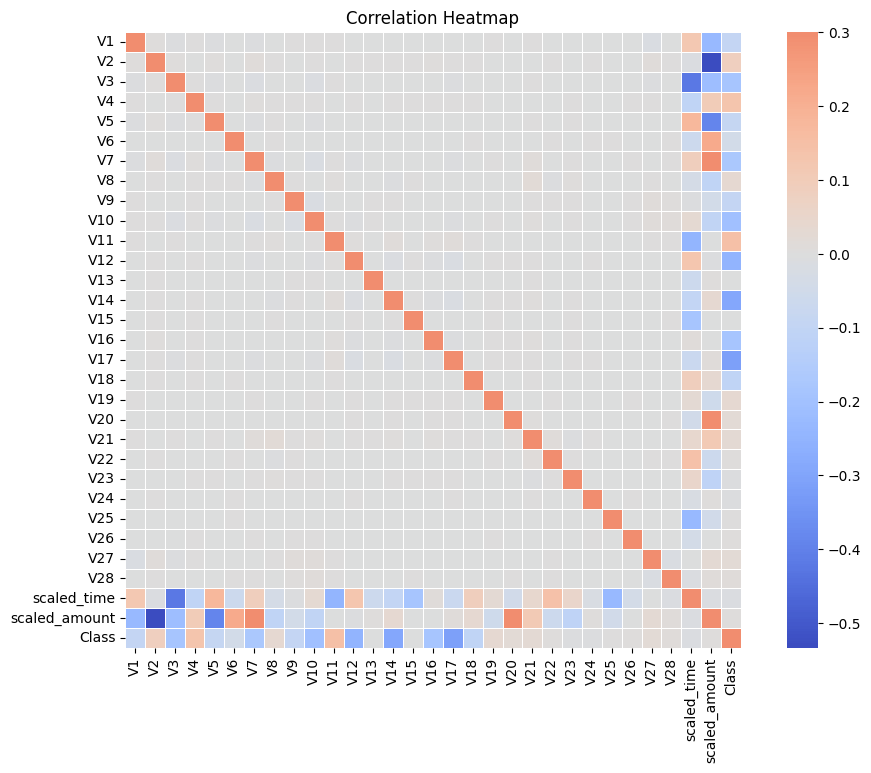

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', vmax=0.3, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


#Feature Selection

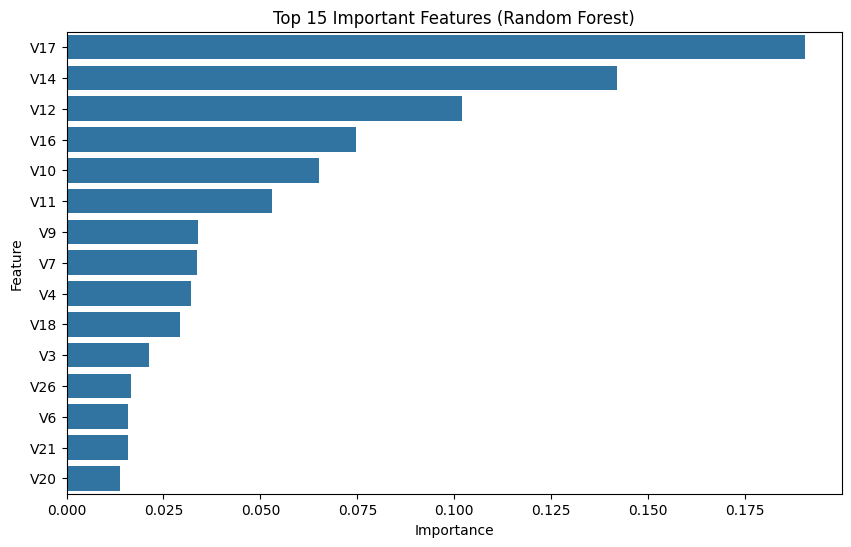

In [ ]:
#Random Forest	(Embedded)	:Handles feature ranking during training

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns

# Create a dataframe
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Important Features (Random Forest)')
plt.show()


In [ ]:
#ANOVA F-test	(Filter)	: Simple statistical test for numeric features
from sklearn.feature_selection import f_classif, SelectKBest

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-score': selector.scores_
}).sort_values(by='F-score', ascending=False)

print(anova_df.head(15))


   Feature       F-score
16     V17  26015.046430
13     V14  22719.847335
11     V12  15743.926556
9      V10  10643.554088
15     V16   8530.799465
2       V3   8396.114493
6       V7   7686.204604
10     V11   5376.453712
3       V4   3884.722043
17     V18   2633.760627
0       V1   2182.755012
8       V9   2099.139575
4       V5   1935.741488
1       V2   1750.568219
5       V6    455.235181


# model building (SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay

Confusion Matrix:
 [[56403   248]
 [   16    79]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.24      0.83      0.37        95

    accuracy                           1.00     56746
   macro avg       0.62      0.91      0.69     56746
weighted avg       1.00      1.00      1.00     56746

Accuracy Score: 0.9953476897050012
ROC AUC Score: 0.9822090751405884


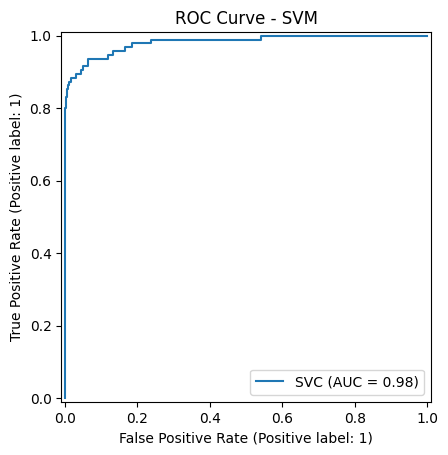

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)

#train the model
svm_model.fit(X_resampled, y_resampled)

#predict on the original test set
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]  #for ROC AUC

# Evaluation Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

#plot ROC Curve
RocCurveDisplay.from_estimator(svm_model, X_test, y_test)
plt.title("ROC Curve - SVM")
plt.show()


explainability

In [ ]:
pip install lime

In [ ]:
# LIME Explanation for SVM Predictions

import lime
import lime.lime_tabular
import numpy as np

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_resampled),
    feature_names=X.columns.tolist(),
    class_names=['Not Fraud', 'Fraud'],
    mode='classification'
)

i = 5
sample = X_test.iloc[i]
sample_array = sample.values.reshape(1, -1)

explanation = explainer.explain_instance(
    data_row=sample,
    predict_fn=svm_model.predict_proba,
    num_features=10
)

print("Actual Class:", y_test.iloc[i])
print("Predicted Class:", svm_model.predict(sample_array)[0])
print("Prediction Probabilities:", svm_model.predict_proba(sample_array))

explanation.show_in_notebook(show_table=True, show_all=False)


Actual Class: 0
Predicted Class: 0
Prediction Probabilities: [[0.97510672 0.02489328]]


In [ ]:
!pip install scikit-learn


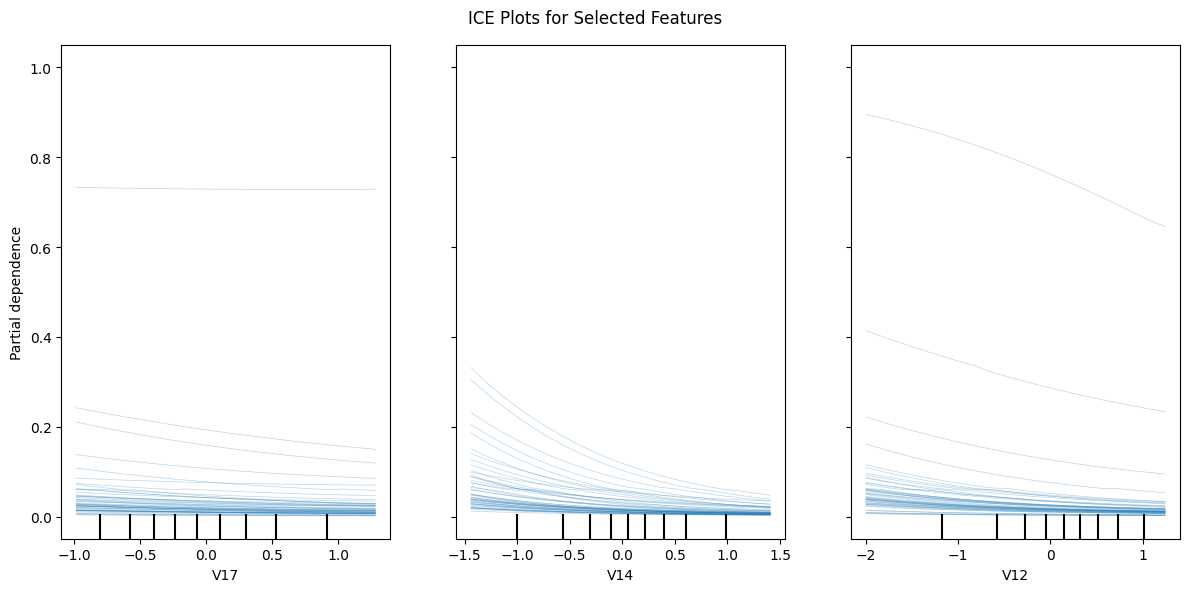

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_to_plot = ['V17', 'V14', 'V12']

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    svm_model, X_test, features=features_to_plot,
    kind="individual", subsample=50, grid_resolution=20,
    ax=ax
)
plt.suptitle("ICE Plots for Selected Features")
plt.tight_layout()
plt.show()

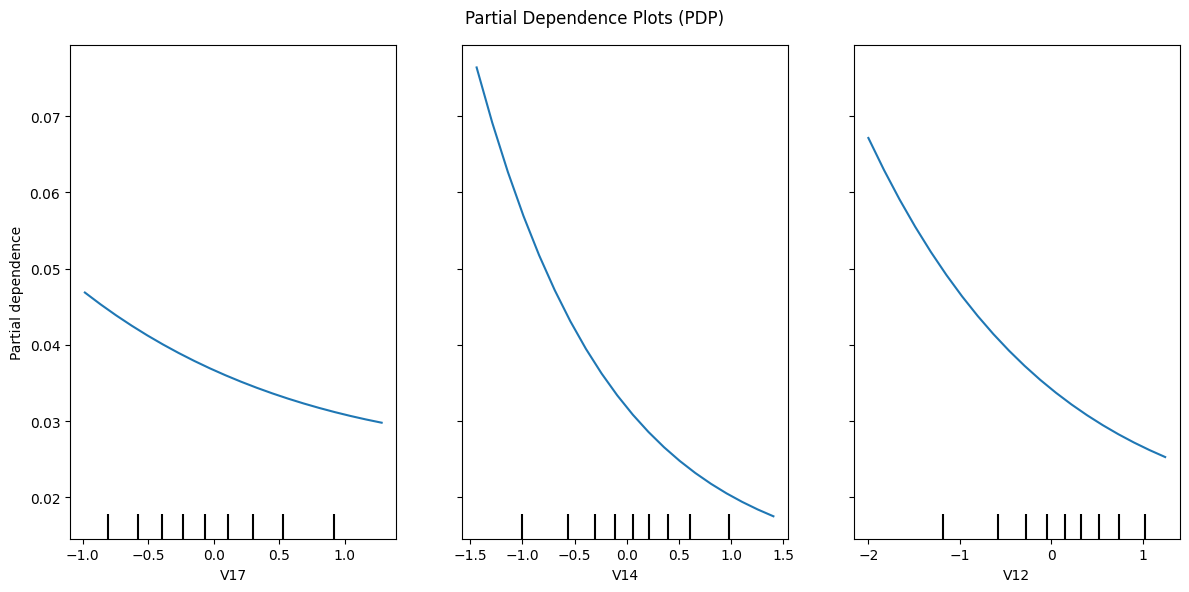

In [ ]:
features_for_pdp = ['V17', 'V14', 'V12']

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    svm_model, X_test, features=features_for_pdp,
    kind="average", grid_resolution=20,
    ax=ax
)
plt.suptitle("Partial Dependence Plots (PDP)")
plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

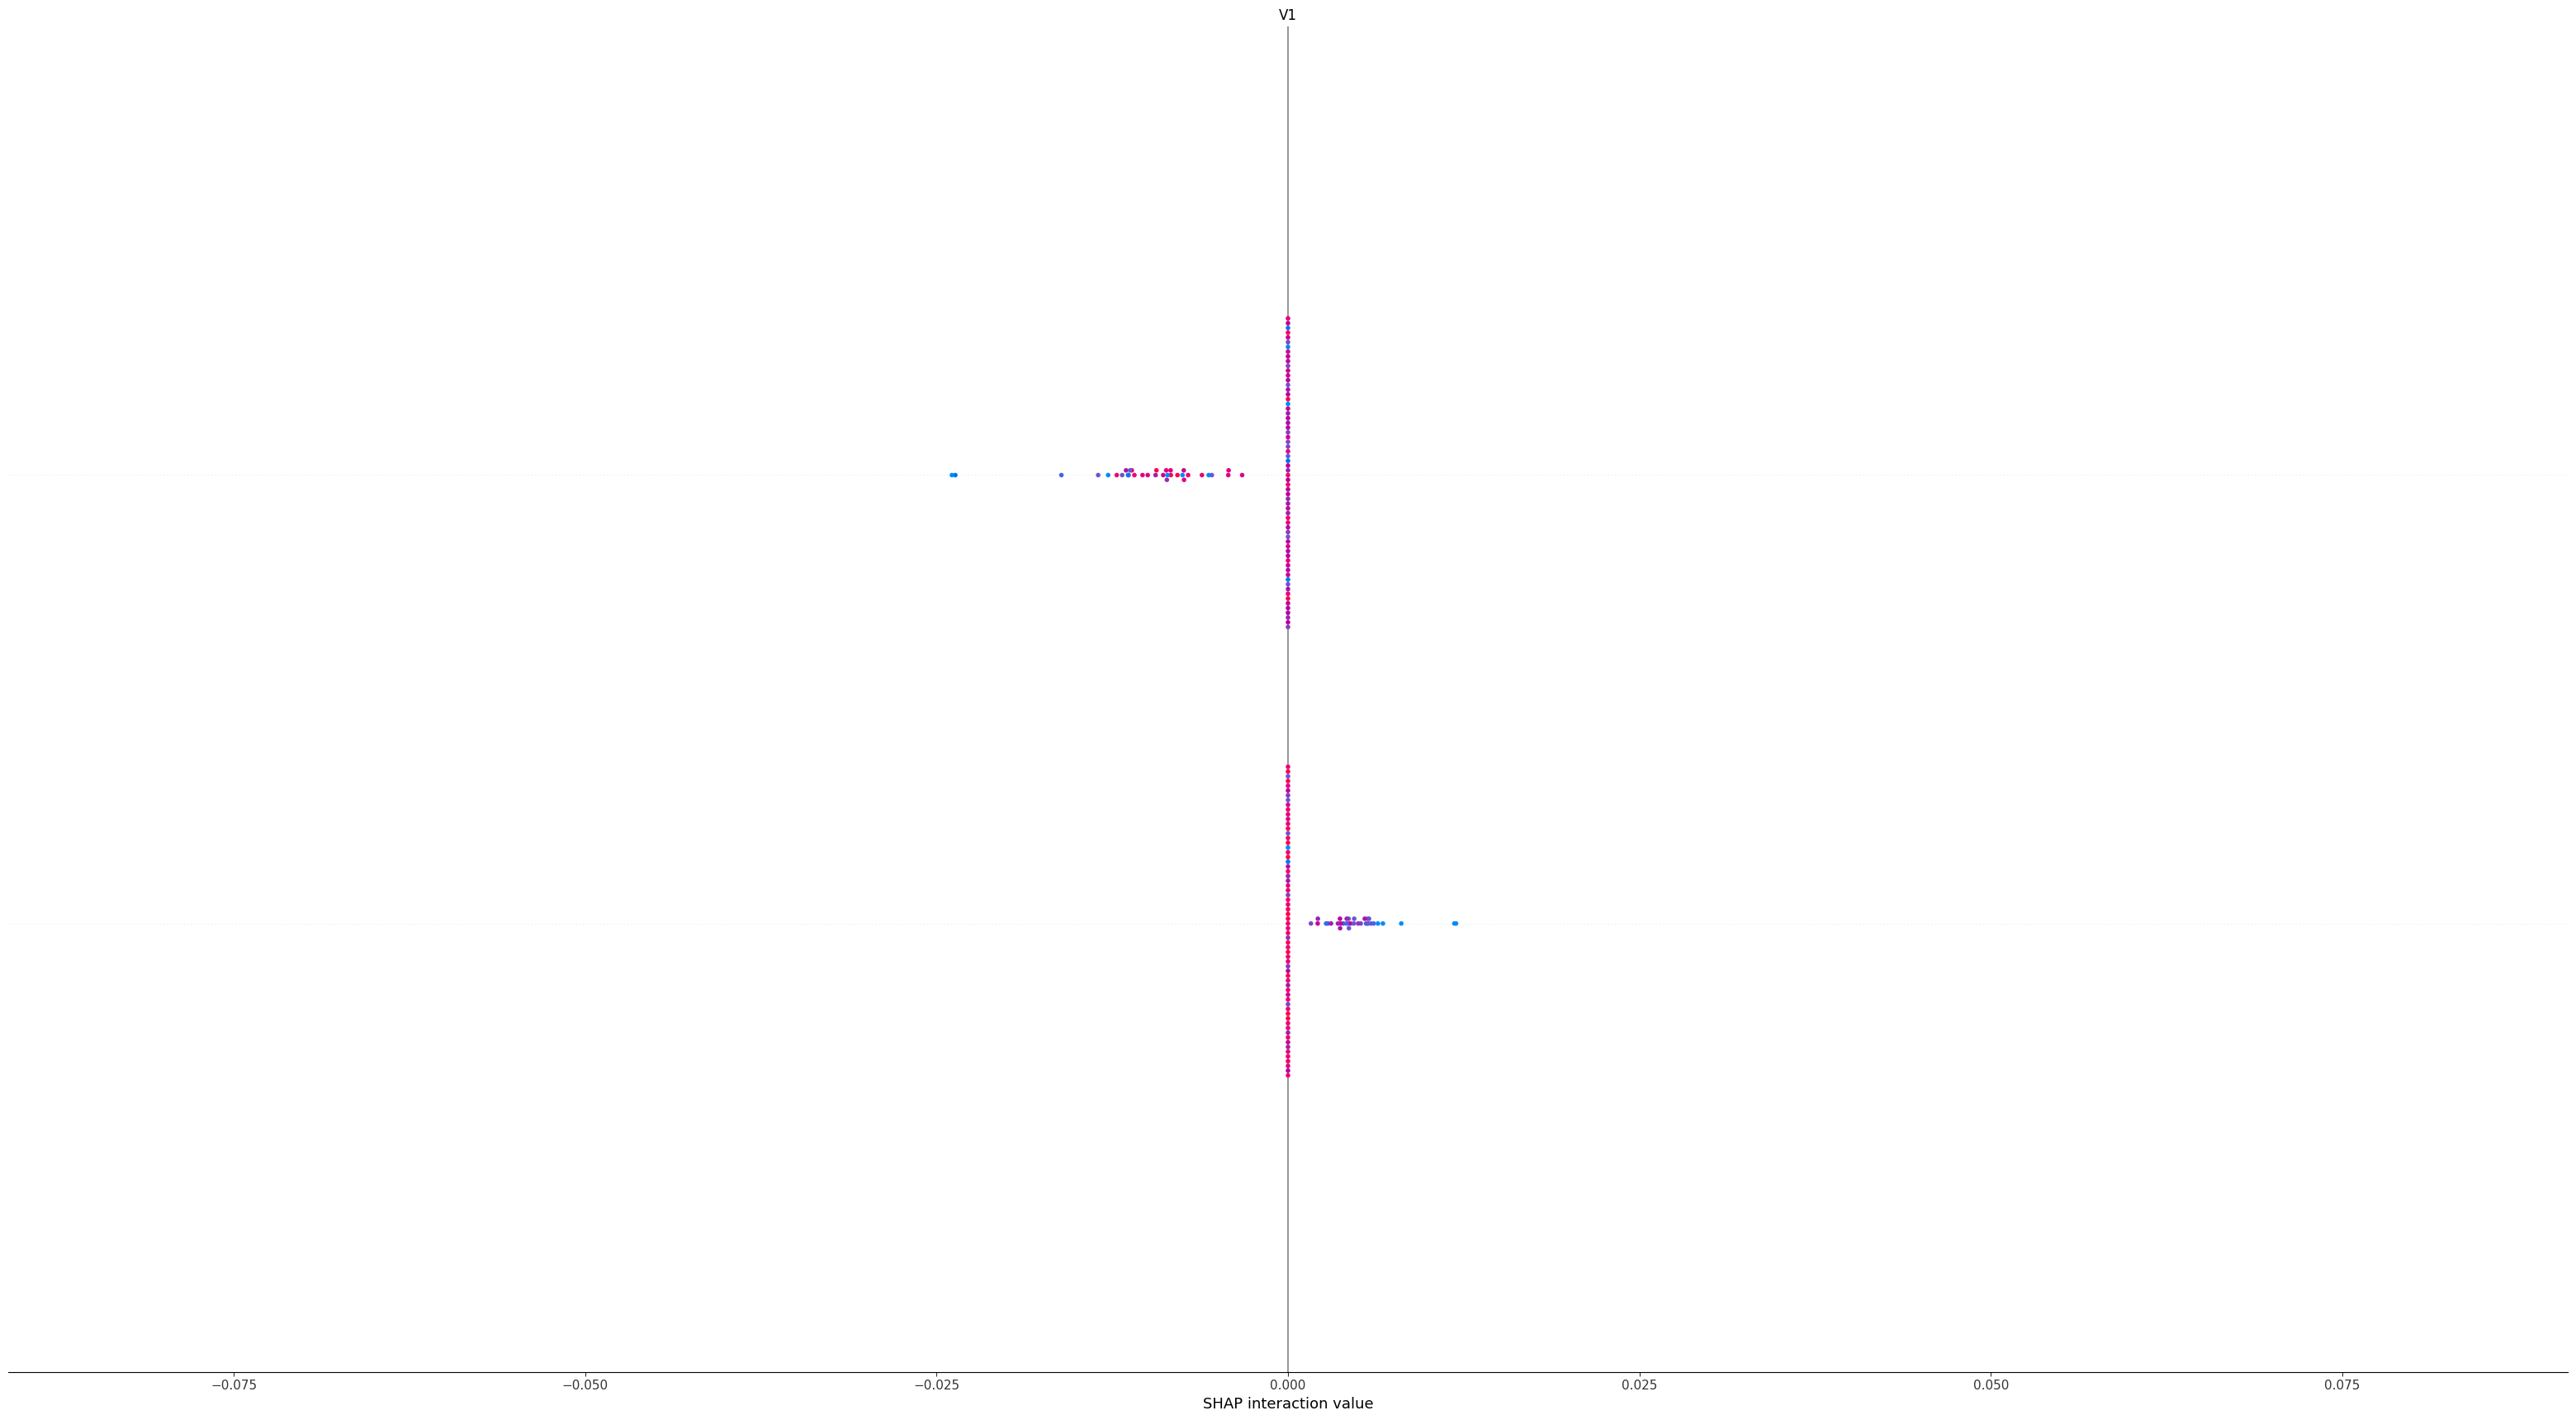

In [ ]:
import shap
import numpy as np

def svm_predict_fn(x):
    return svm_model.predict_proba(x)

background = shap.kmeans(X_resampled, 50)

explainer = shap.KernelExplainer(svm_predict_fn, background)

shap_values = explainer.shap_values(X_test[:100])

shap.summary_plot(shap_values, X_test[:100], max_display=20)


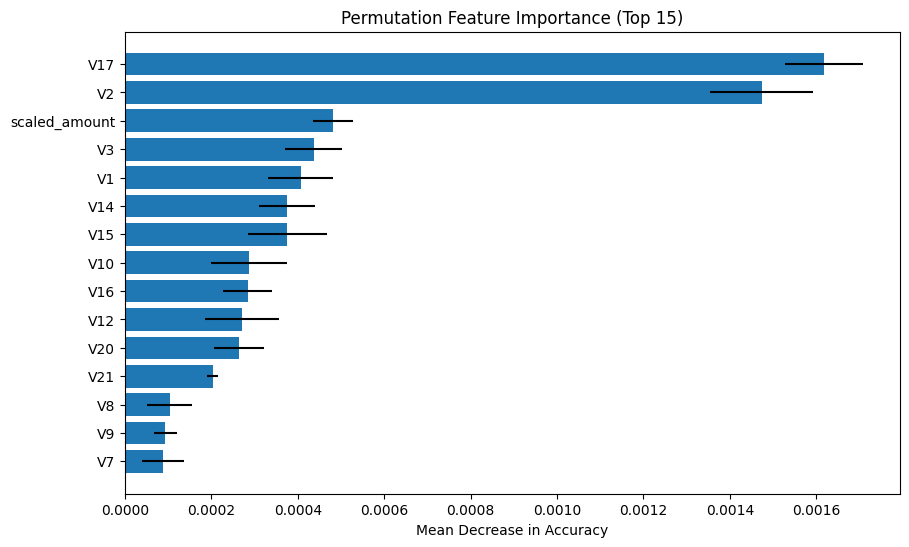

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm_model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance Mean': result.importances_mean,
    'Importance Std': result.importances_std
}).sort_values(by='Importance Mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'][:15], perm_df['Importance Mean'][:15], xerr=perm_df['Importance Std'][:15])
plt.gca().invert_yaxis()
plt.title('Permutation Feature Importance (Top 15)')
plt.xlabel('Mean Decrease in Accuracy')
plt.show()


#ANN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
ann_model = Sequential()
ann_model.add(Dense(32, input_dim=X_resampled.shape[1], activation='relu'))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

In [ ]:
ann_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
history = ann_model.fit(X_resampled, y_resampled, epochs=50, batch_size=64, validation_split=0.2, callbacks=[early_stopping], verbose=1)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6343 - loss: 0.6246 - val_accuracy: 0.0021 - val_loss: 2.6847
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9958 - loss: 0.2771 - val_accuracy: 0.0000e+00 - val_loss: 5.1794
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1189 - val_accuracy: 0.0000e+00 - val_loss: 7.7934
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0564 - val_accuracy: 0.0000e+00 - val_loss: 10.2058
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0324 - val_accuracy: 0.0000e+00 - val_loss: 12.2551
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0190 - val_accuracy: 0.0000e+00 - val_loss: 13.9061


1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Confusion Matrix:
 [[56459   192]
 [   95     0]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.00      0.00      0.00        95

    accuracy                           0.99     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      0.99      1.00     56746

ROC AUC Score: 0.22599164412947606
Accuracy Score: 0.9949423747929369


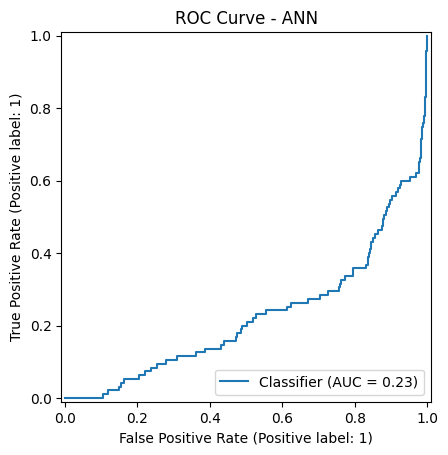

In [ ]:
y_pred_ann = (ann_model.predict(X_test) > 0.5).astype(int).flatten()
y_proba_ann = ann_model.predict(X_test).flatten()

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ann))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ann))

print("ROC AUC Score:", roc_auc_score(y_test, y_proba_ann))
print("Accuracy Score:", accuracy_score(y_test, y_pred_ann))

RocCurveDisplay.from_predictions(y_test, y_proba_ann)
plt.title("ROC Curve - ANN")
plt.show()

EXPLAINABILITY

In [ ]:
def ann_predict_fn(x):
    proba = ann_model.predict(x)
    return np.hstack((1 - proba, proba))

explainer_ann = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_resampled),
    feature_names=X.columns.tolist(),
    class_names=['Not Fraud', 'Fraud'],
    mode='classification'
)

i = 5
sample = X_test.iloc[i]
sample_array = sample.values.reshape(1, -1)

explanation = explainer_ann.explain_instance(
    data_row=sample,
    predict_fn=ann_predict_fn,
    num_features=10
)

print("Actual Class:", y_test.iloc[i])
print("Predicted Class:", ann_model.predict(sample_array).round()[0][0])
print("Prediction Probabilities:", ann_predict_fn(sample_array))

explanation.show_in_notebook(show_table=True, show_all=False)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Actual Class: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Class: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction Probabilities: [[0.7712639  0.22873609]]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
3294/3294 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

<Figure size 640x480 with 0 Axes>

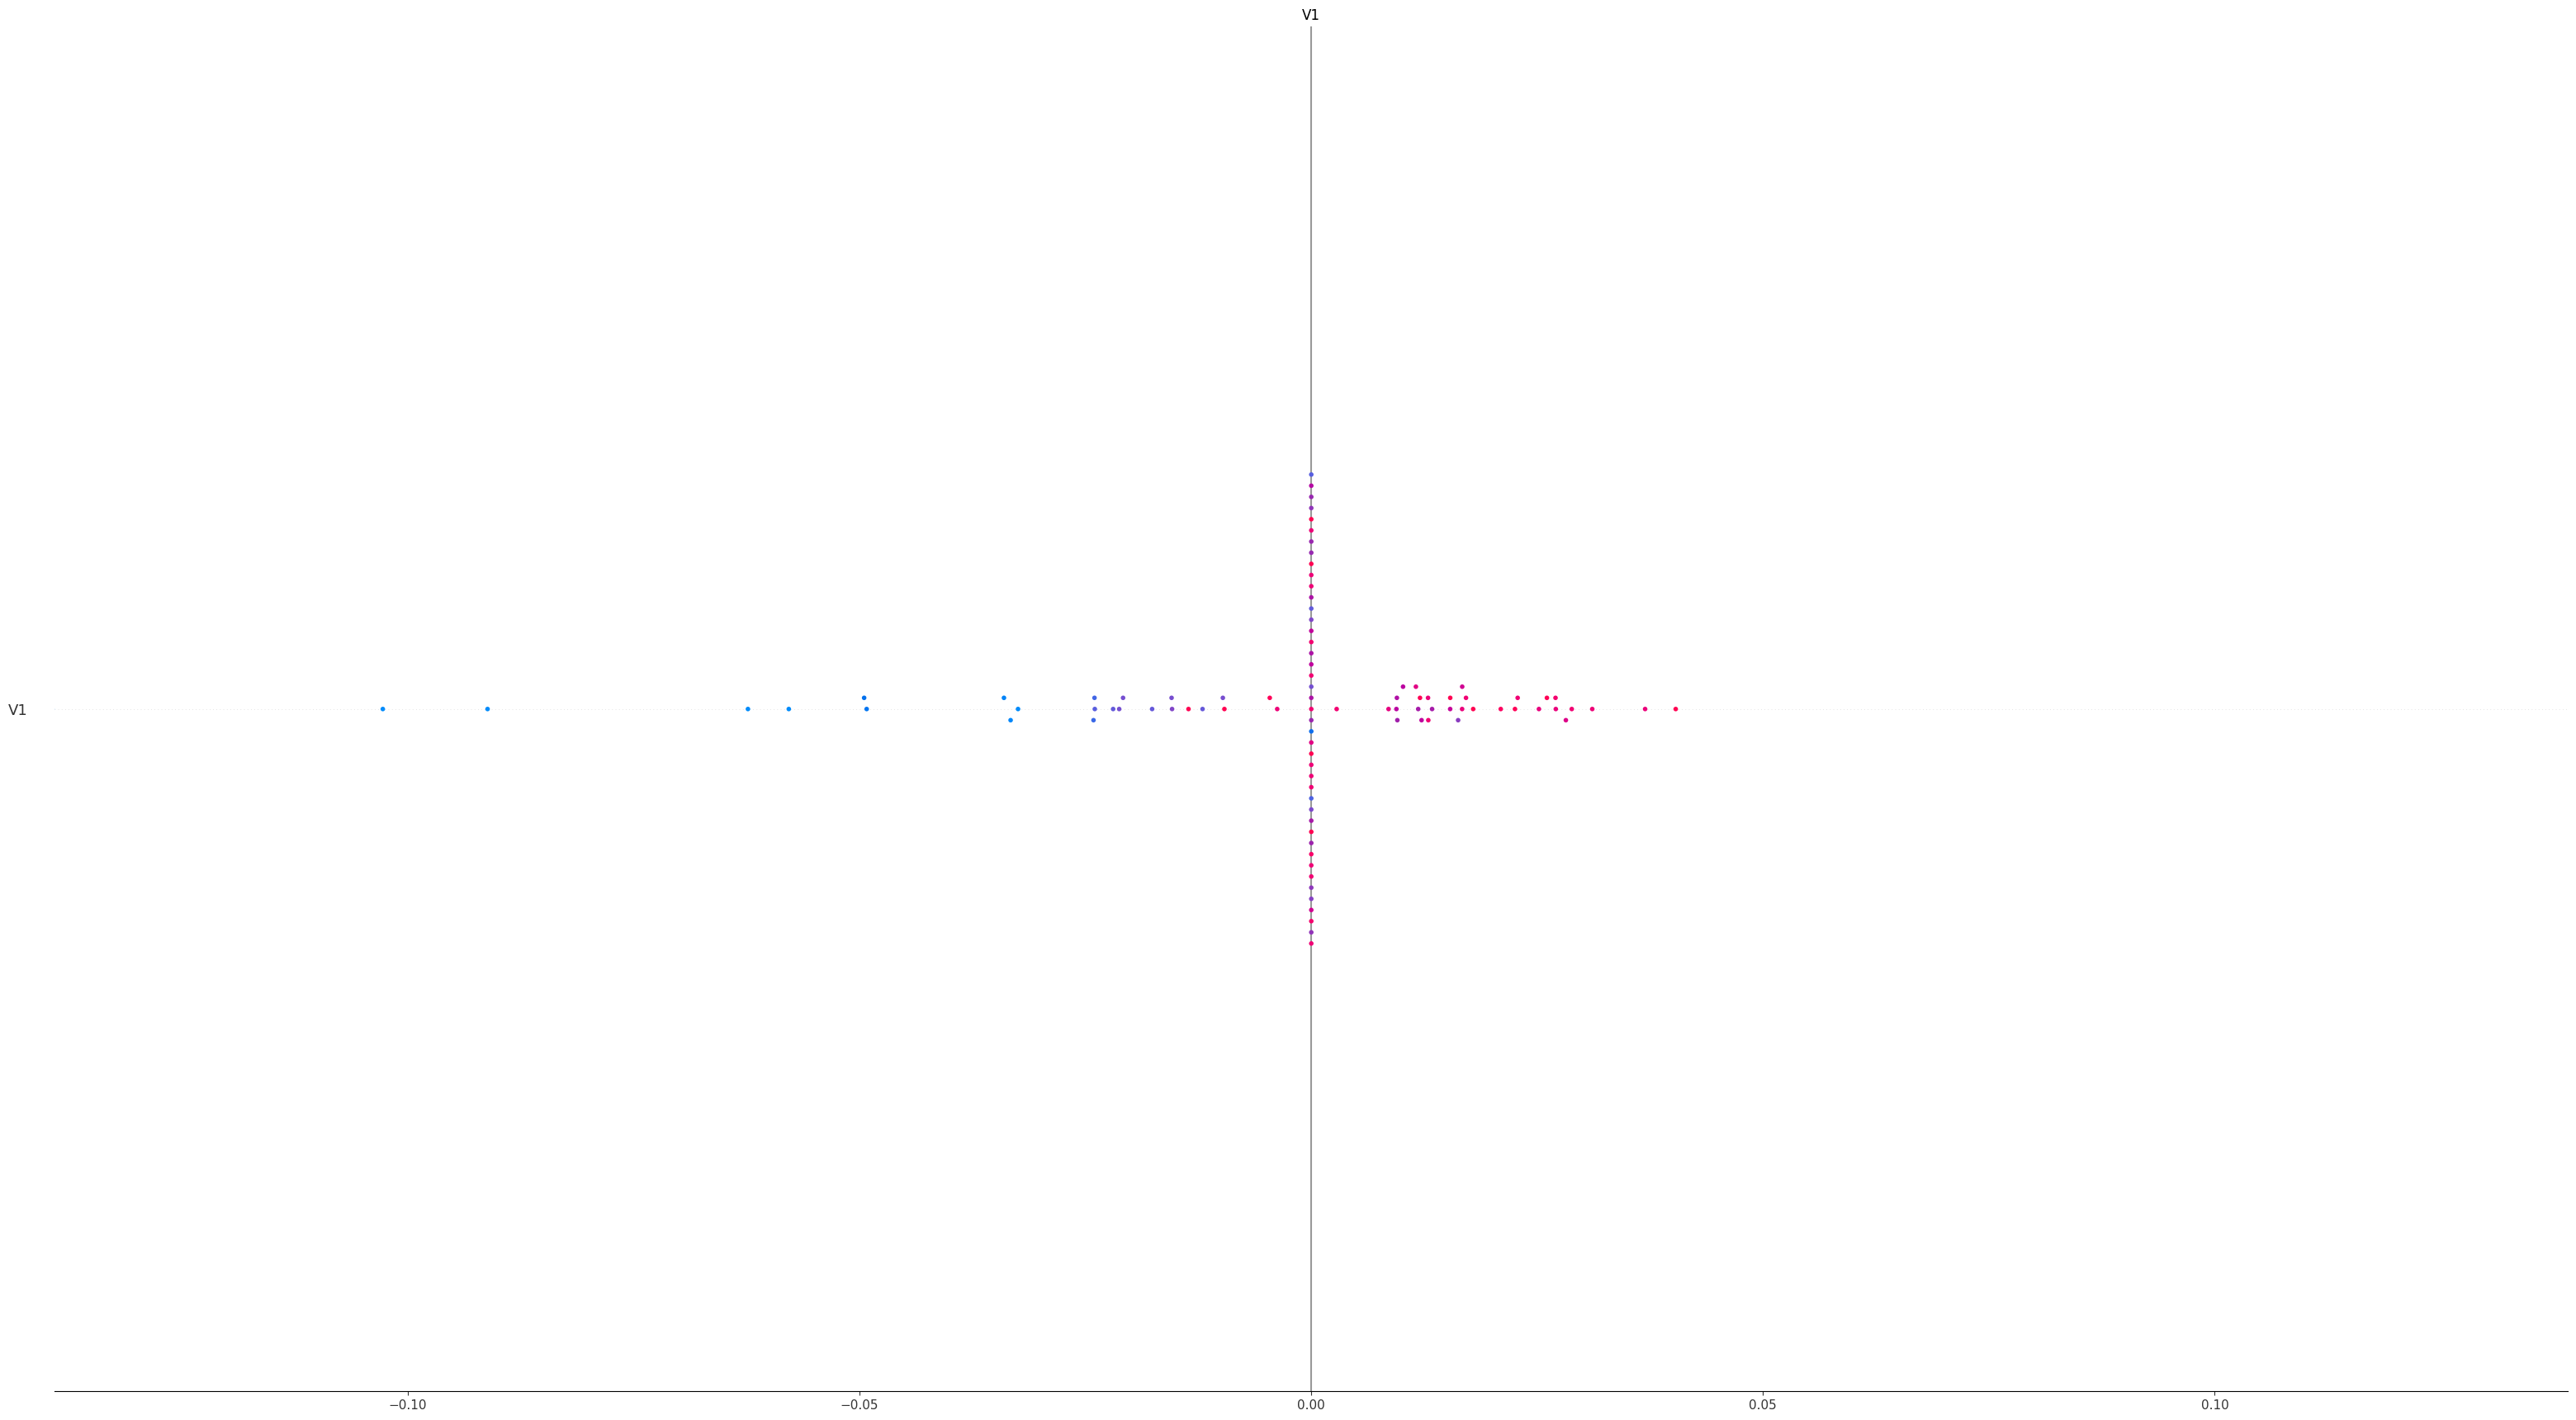

In [ ]:
background_ann = shap.kmeans(X_resampled, 50)
explainer_ann_shap = shap.KernelExplainer(ann_model.predict, background_ann)
shap_values_ann = explainer_ann_shap.shap_values(X_test[:100])

shap.summary_plot(shap_values_ann, X_test[:100], max_display=20)


1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━

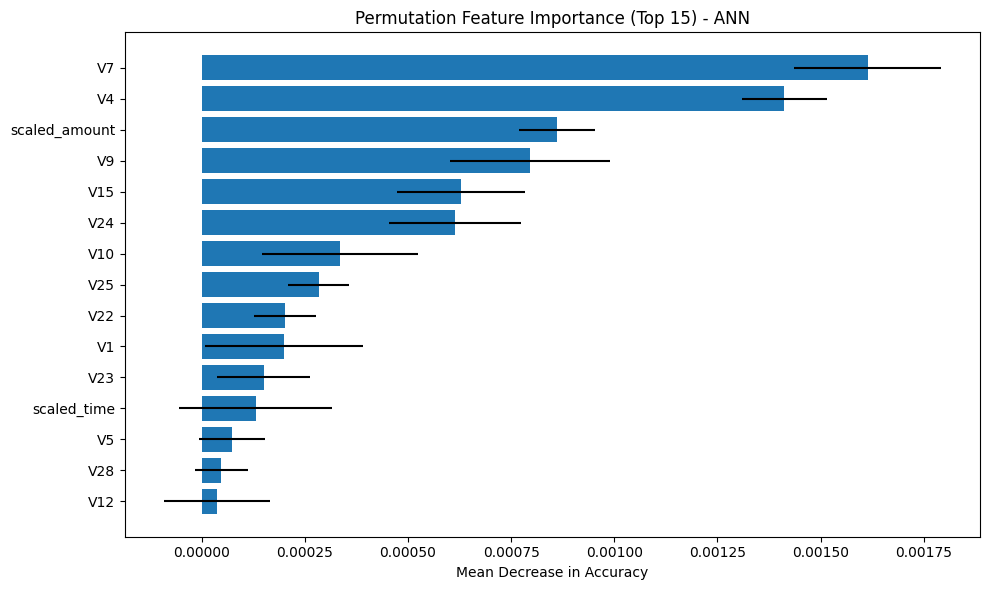

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self._estimator_type = "classifier"

    def fit(self, X, y):
        self.fitted_ = True
        return self

    def predict(self, X):
        return (self.model.predict(X) > 0.5).astype(int).flatten()

    def predict_proba(self, X):
        proba = self.model.predict(X).flatten()
        return np.vstack([1 - proba, proba]).T

ann_wrapper = KerasClassifierWrapper(ann_model)
ann_wrapper.fit(X_test, y_test)

perm_result_ann = permutation_importance(
    ann_wrapper, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance Mean': perm_result_ann.importances_mean,
    'Importance Std': perm_result_ann.importances_std
}).sort_values(by='Importance Mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'][:15], perm_df['Importance Mean'][:15], xerr=perm_df['Importance Std'][:15])
plt.gca().invert_yaxis()
plt.title('Permutation Feature Importance (Top 15) - ANN')
plt.xlabel('Mean Decrease in Accuracy')
plt.tight_layout()
plt.show()


In [ ]:
pip install lofo-importance


1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1774/1774 ━

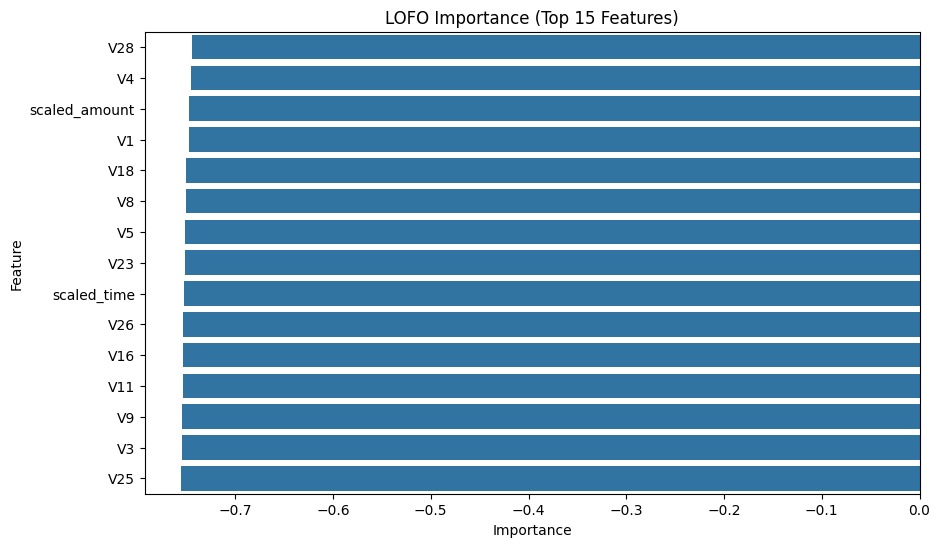

In [ ]:
from sklearn.metrics import roc_auc_score
import copy

y_proba_all = ann_model.predict(X_test).flatten()
baseline_auc = roc_auc_score(y_test, y_proba_all)

lofo_scores = []

for col in X_test.columns:
    X_test_lofo = X_test.drop(columns=[col])
    X_resampled_lofo = X_resampled.drop(columns=[col])

    model_clone = Sequential()
    model_clone.add(Dense(32, input_dim=X_resampled_lofo.shape[1], activation='relu'))
    model_clone.add(Dropout(0.3))
    model_clone.add(Dense(16, activation='relu'))
    model_clone.add(Dense(1, activation='sigmoid'))

    model_clone.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    model_clone.fit(X_resampled_lofo, y_resampled, epochs=10, batch_size=64, verbose=0)

    X_test_lofo_values = X_test_lofo.values
    y_proba_lofo = model_clone.predict(X_test_lofo_values).flatten()
    auc_lofo = roc_auc_score(y_test, y_proba_lofo)

    importance = baseline_auc - auc_lofo
    lofo_scores.append((col, importance))

lofo_df = pd.DataFrame(lofo_scores, columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=lofo_df.head(15), x='Importance', y='Feature')
plt.title('LOFO Importance (Top 15 Features)')
plt.show()


#XGBOOST

Confusion Matrix:
 [[56290   361]
 [    0    95]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.21      1.00      0.34        95

    accuracy                           0.99     56746
   macro avg       0.60      1.00      0.67     56746
weighted avg       1.00      0.99      1.00     56746

ROC AUC Score: 0.999806757719704
Accuracy Score: 0.9936383181193388


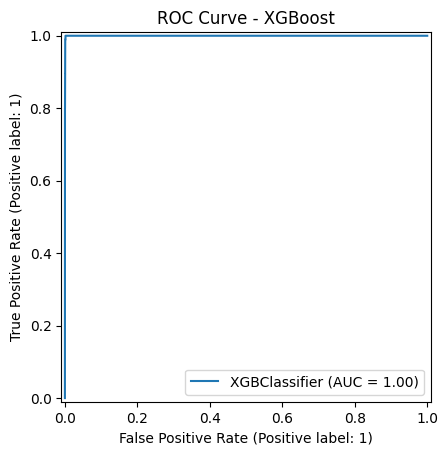

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_resampled, y_resampled)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))
print("Accuracy Score:", accuracy_score(y_test, y_pred_xgb))

RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("ROC Curve - XGBoost")
plt.show()


EXPLAINABILITY

In [ ]:
explainer_xgb = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_resampled),
    feature_names=X.columns.tolist(),
    class_names=['Not Fraud', 'Fraud'],
    mode='classification'
)

i = 5
sample = X_test.iloc[i]
sample_array = sample.values.reshape(1, -1)

explanation_xgb = explainer_xgb.explain_instance(
    data_row=sample,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

print("Actual Class:", y_test.iloc[i])
print("Predicted Class:", xgb_model.predict(sample_array)[0])
explanation_xgb.show_in_notebook(show_table=True, show_all=False)


Actual Class: 0
Predicted Class: 0


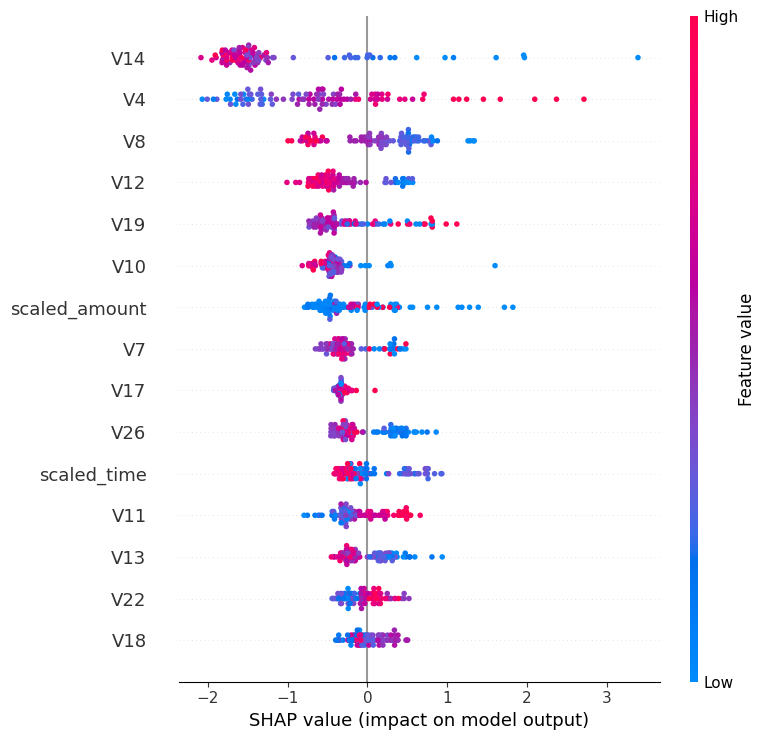

In [ ]:
explainer_shap_xgb = shap.Explainer(xgb_model, X_resampled)
shap_values_xgb = explainer_shap_xgb(X_test[:100])

shap.summary_plot(shap_values_xgb, X_test[:100], max_display=15)


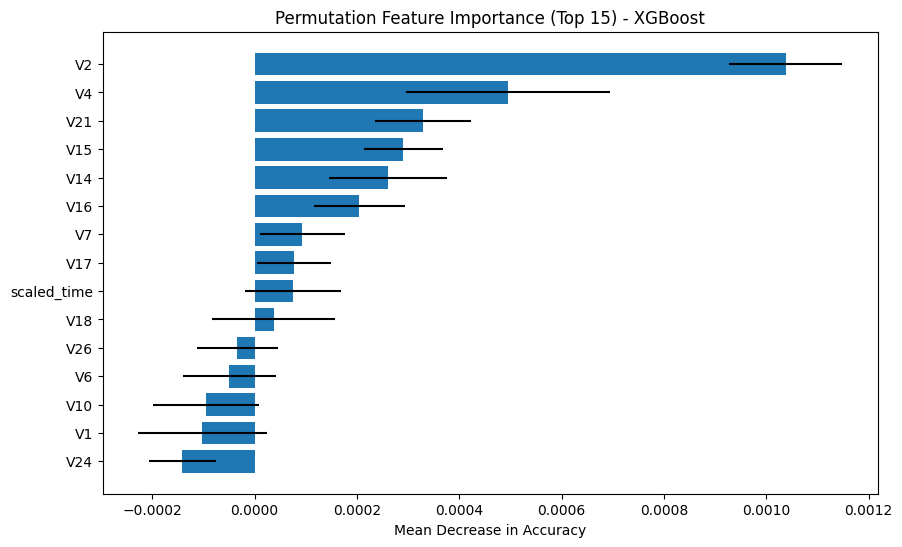

In [ ]:
perm_result_xgb = permutation_importance(
    xgb_model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy'
)

perm_df_xgb = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance Mean': perm_result_xgb.importances_mean,
    'Importance Std': perm_result_xgb.importances_std
}).sort_values(by='Importance Mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df_xgb['Feature'][:15], perm_df_xgb['Importance Mean'][:15], xerr=perm_df_xgb['Importance Std'][:15])
plt.gca().invert_yaxis()
plt.title('Permutation Feature Importance (Top 15) - XGBoost')
plt.xlabel('Mean Decrease in Accuracy')
plt.show()


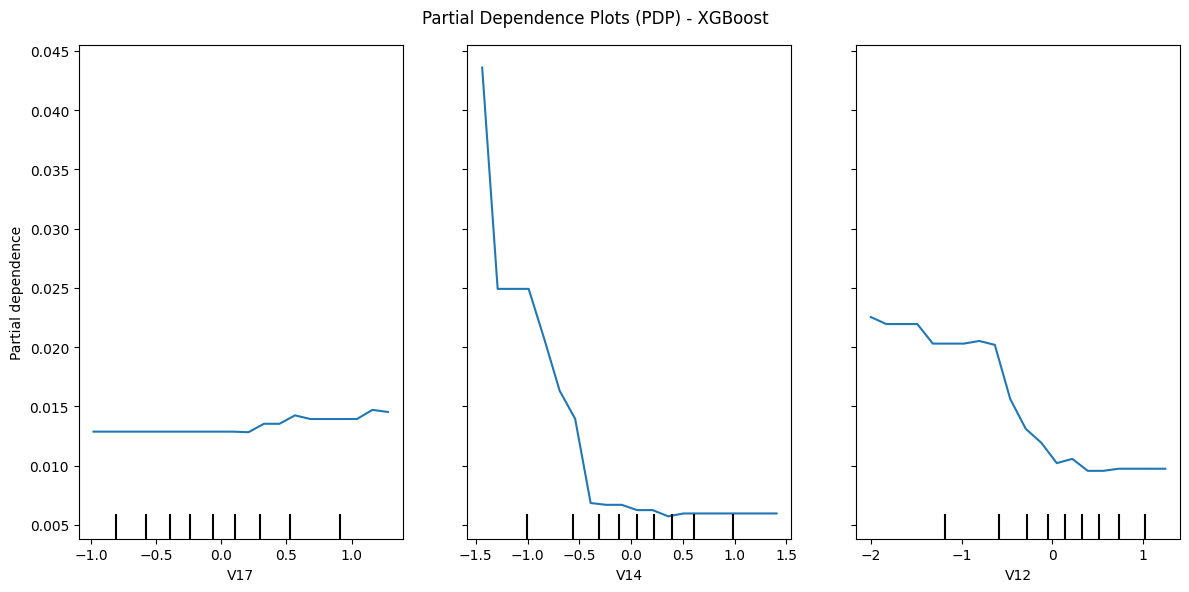

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    xgb_model, X_test, features=['V17', 'V14', 'V12'],
    kind="average", grid_resolution=20, ax=ax
)
plt.suptitle("Partial Dependence Plots (PDP) - XGBoost")
plt.tight_layout()
plt.show()
